# 2D Poisson Equation

The **Poisson equation** is a fundamental partial differential equation (PDE) in mathematical physics, describing phenomena such as electrostatics, heat distribution, and fluid flow. In two dimensions, it is typically written as:

$$-\Delta u(x, y) = f(x, y), \quad (x, y) \in \Omega,$$

with appropriate boundary conditions on the domain $\Omega \subset \mathbb{R}^2$.

In this notebook, we approach the Poisson problem using **Discrete Exterior Calculus (DEC)**, a geometric framework for discretizing differential forms and operators on meshes. DEC provides a natural way to encode the underlying geometric and topological structure of PDEs, offering advantages such as:

- Coordinate-free formulation suitable for arbitrary meshes.
- Exact representation of key geometric operators like the exterior derivative and Hodge star.
- Preservation of fundamental properties like divergence-free fields and Stokes' theorem at the discrete level.

Here, we will:

1. Define a 2D mesh representing the computational domain.
2. Assemble and solve the linear system corresponding to the Poisson equation.
3. Visualize the solution and examine convergence behavior.

By the end of this notebook, you will have a working DEC-based solver for the 2D Poisson equation and a deeper understanding of how discrete differential geometry can be used for PDEs on complex domains.

## Imports

In [1]:
import numpy as np
import jax.numpy as jnp
import jax
import dctkit as dt
from dctkit.mesh import util
from dctkit.physics import poisson as p
from dctkit.dec import cochain as C
from dctkit.math.opt import optctrl as oc
from functools import partial
import matplotlib.pyplot as plt
from matplotlib import tri
import pyvista as pv
from pyvista import themes

In [32]:
# this must be called at the beginning of every script using dctkit
# to set the floating point precision
dt.config()

## Complex generation and plotting

In [3]:
lc = 0.2

mesh, _ = util.generate_square_mesh(lc)
S = util.build_complex_from_mesh(mesh)
S.get_hodge_star()
bnodes = mesh.cell_sets_dict["boundary"]["line"]
node_coord = S.node_coords

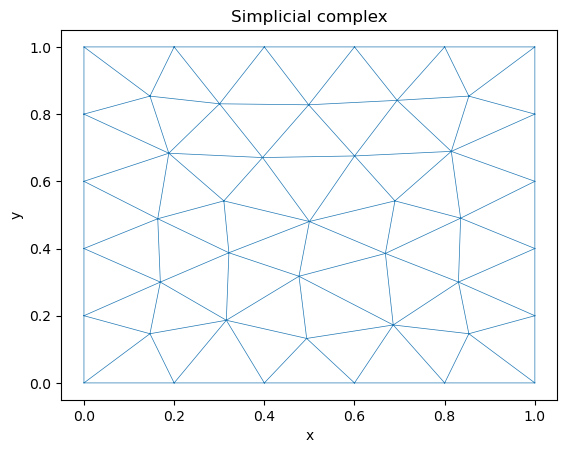

In [4]:
# mesh plot
plt.triplot(S.node_coords[:, 0], S.node_coords[:, 1], triangles=S.S[2],  linewidth=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Simplicial complex")
plt.show()

In [5]:
k = 1.

# NOTE: exact solution of Delta u + f = 0
u_true = np.array(node_coord[:, 0]**2 + node_coord[:, 1]
                  ** 2, dtype=dt.float_dtype)
b_values = u_true[bnodes]

boundary_values = (np.array(bnodes, dtype=dt.int_dtype), b_values)

num_nodes = S.num_nodes
f_vec = -4.*np.ones((num_nodes, 1), dtype=dt.float_dtype)
f = C.Cochain(0, True, S, f_vec)
star_f = C.star(f)

mask = np.ones((num_nodes, 1), dtype=dt.float_dtype)
mask[bnodes, :] = 0.

# initial guess (notice that this is a row vector)
u_0 = 0.01*np.random.rand(num_nodes).astype(dt.float_dtype)
u_0 = np.array(u_0, dtype=dt.float_dtype)

# penalty parameter
gamma = 1000.

## Variational Formulation

In the continuous setting, the Poisson equation can be derived as the stationarity condition of the **Dirichlet functional**, which consists of two parts: the $L^2$ norm of the gradient of the unknown field, and the $L^2$ inner product between the unknown and the source term.  

In our setting, we can define a corresponding **discrete Dirichlet energy** by representing the unknown $u$ and source $f$ as primal scalar-valued $0$-cochains:

$$\mathcal{E}_{\mathrm{p}}(u) = \frac{1}{2} \langle du, du \rangle - \langle u, f \rangle
= \frac{1}{2} \langle \delta du, u \rangle - \langle u, f \rangle.$$

Here, $du$ is the coboundary of $u$, a primal 1-cochain whose entries approximate the integral of the gradient along mesh edges. Each term in this discrete energy retains the same **physical and geometric meaning** as in the continuous case.

In [6]:
def energy_poisson(x, f, k, boundary_values, gamma):
    pos, value = boundary_values
    f_coch = C.CochainP0(S, f)
    u = C.CochainP0(S, x)
    du = C.coboundary(u)
    norm_grad = k/2*C.inner(du, du)
    bound_term = -C.inner(u, f_coch)
    penalty = 0.5*gamma*np.sum((x[pos] - value)**2)
    energy = norm_grad + bound_term + penalty
    return energy

In [7]:
obj = partial(p.energy_poisson, S=S)
args = {'f': f_vec, 'k': k, 'boundary_values': boundary_values, 'gamma': gamma}

In [8]:
prb = oc.OptimizationProblem(dim=num_nodes, state_dim=num_nodes, objfun=obj)
prb.set_obj_args(args)
u_var = prb.solve(u_0, algo="lbfgs").astype(dt.float_dtype)

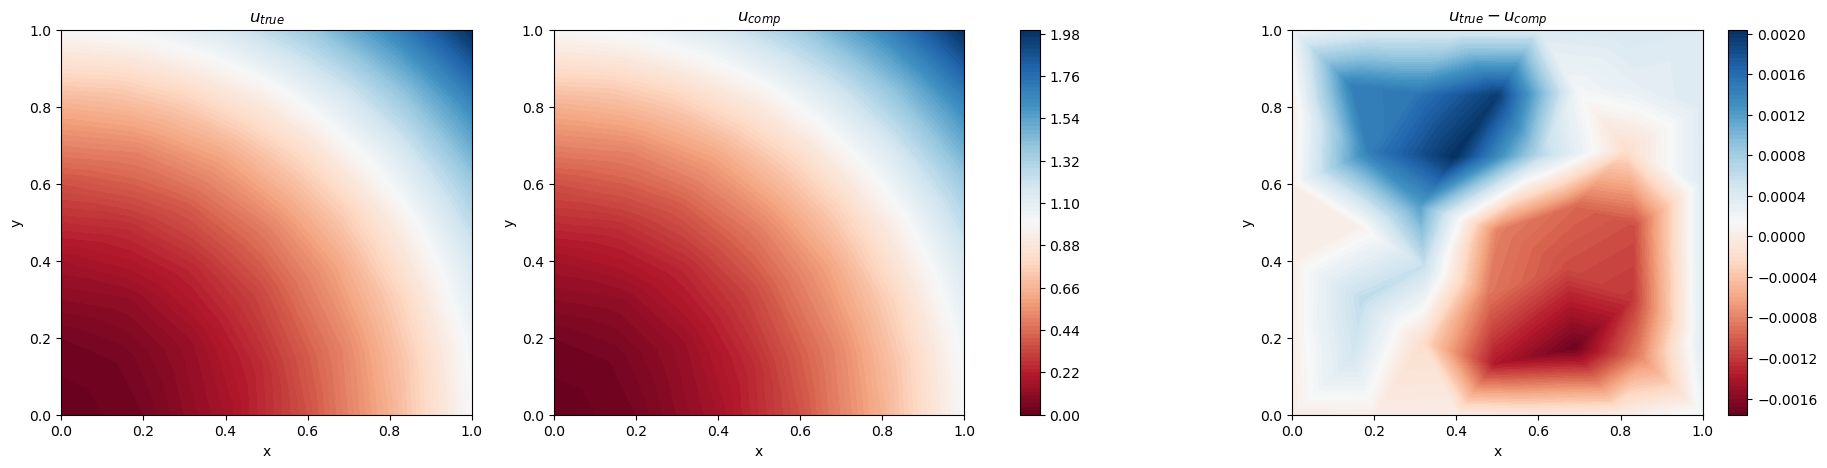

In [9]:
# contour plot
triang = tri.Triangulation(S.node_coords[:, 0], S.node_coords[:, 1], S.S[2])
plt.figure(1, figsize=(22.5, 5))
_, ax = plt.subplots(1, 3, num=1)

vmin = min(u_true.min(), u_var.min())
vmax = max(u_true.max(), u_var.max())

u_true_plot = ax[0].tricontourf(
    triang, u_true, cmap="RdBu", vmin=vmin, vmax=vmax, levels=100
)
u_plot = ax[1].tricontourf(
    triang, u_var, cmap="RdBu", vmin=vmin, vmax=vmax, levels=100
)
res_plot = ax[2].tricontourf(triang, u_true - u_var, cmap="RdBu", levels=100)

plt.colorbar(u_true_plot, ax=[ax[0], ax[1]], orientation="vertical")
plt.colorbar(res_plot, ax=ax[2], orientation="vertical")
for i in range(3):
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("y")

ax[0].set_title(r"$u_{true}$")
ax[1].set_title(r"$u_{comp}$")
ax[2].set_title(r"$u_{true} - u_{comp}$")
plt.show()

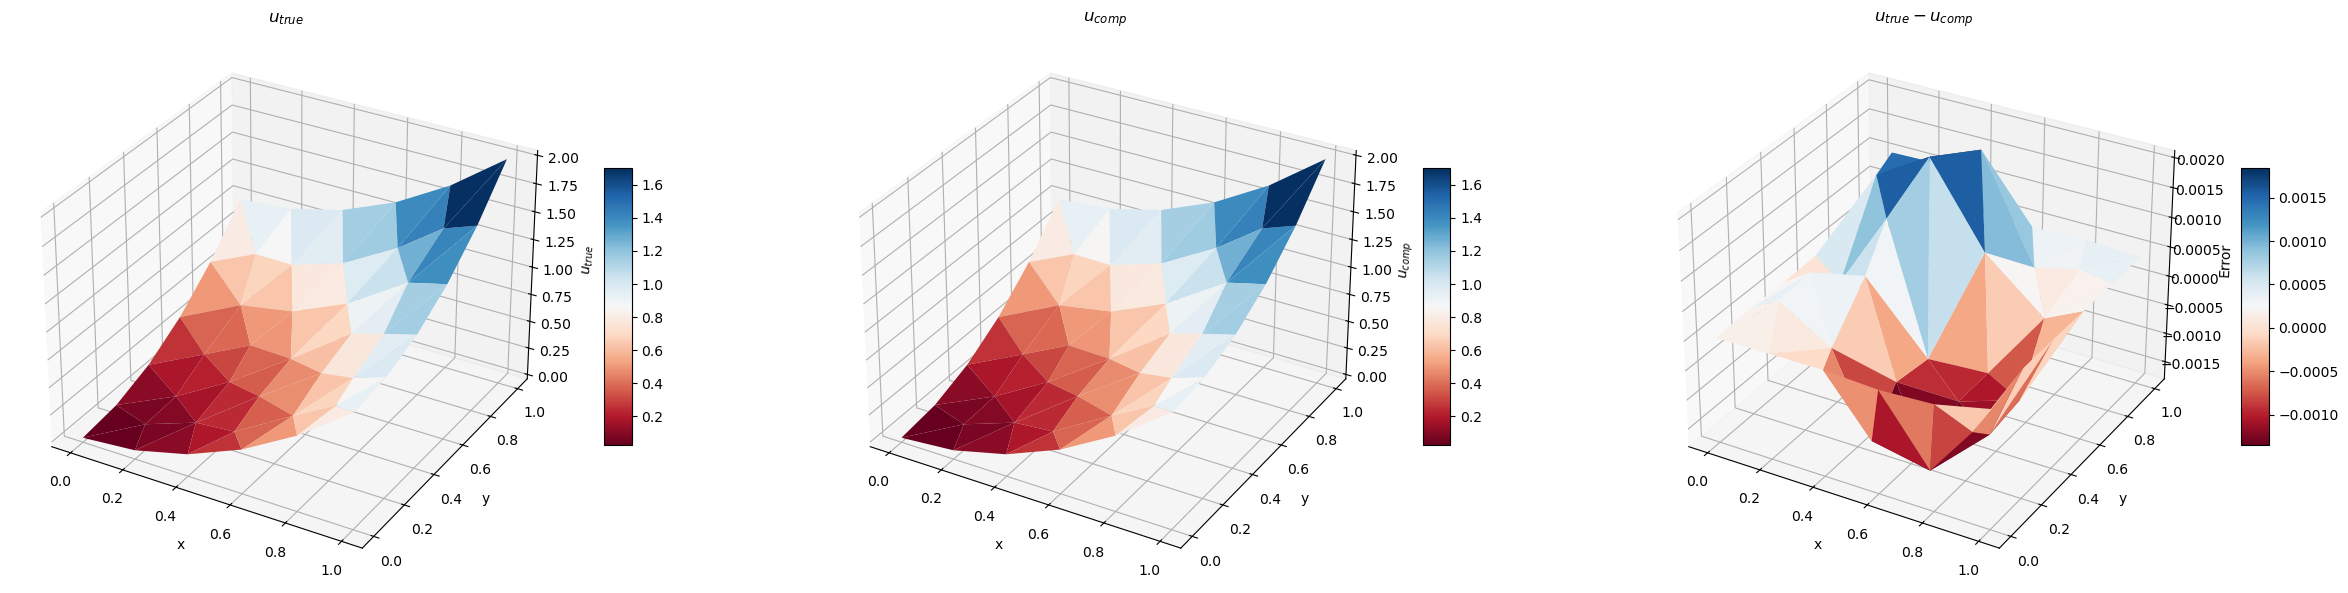

In [10]:
# Surface plot
fig = plt.figure(figsize=(25, 6))
ax0 = fig.add_subplot(1, 3, 1, projection="3d")

surf0 = ax0.plot_trisurf(
    triang, u_true, cmap="RdBu", linewidth=0.2, antialiased=True
)
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_zlabel(r"$u_{true}$")
ax0.set_title(r"$u_{true}$")
fig.colorbar(surf0, ax=ax0, shrink=0.5, aspect=10)
ax1 = fig.add_subplot(1, 3, 2, projection="3d")
surf1 = ax1.plot_trisurf(
    triang, u_var, cmap="RdBu", linewidth=0.2, antialiased=True
)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel(r"$u_{comp}$")
ax1.set_title(r"$u_{comp}$")
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(1, 3, 3, projection="3d")
surf2 = ax2.plot_trisurf(
    triang, u_true - u_var, cmap="RdBu", linewidth=0.2, antialiased=True
)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("Error")
ax2.set_title(r"$u_{true} - u_{comp}$")
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

## Non-variational formulation

The **discrete Poisson equation** is written as:
$$\delta d u + f = 0 \quad \text{or equivalently} \quad \star d \star d u + f = 0,$$

where $\delta$ is the (discrete) codifferential, $d$ is the coboundary and $\star$ is the (discrete) Hodge star.

In [11]:
def obj_poisson(x, f, k, boundary_values, gamma, mask):
    pos, value = boundary_values
    c = C.Cochain(0, True, S, x)
    # compute Laplace-de Rham of c
    laplacian = C.laplacian(c)
    # the Laplacian on forms is the negative of the Laplacian on scalar
    # fields
    laplacian.coeffs *= -k
    # compute the residual of the Poisson equation k*Delta u + f = 0
    r = laplacian.coeffs + f
    penalty = jnp.sum((x[pos] - value)**2)
    obj = 0.5*jnp.linalg.norm(r*mask)**2 + 0.5*gamma*penalty
    return obj

In [12]:
args = {'f': f_vec, 'k': k, 'boundary_values': boundary_values, 'gamma': gamma, 'mask': mask}
obj = obj_poisson

In [13]:
prb = oc.OptimizationProblem(dim=num_nodes, state_dim=num_nodes, objfun=obj)
prb.set_obj_args(args)
u_res = prb.solve(u_0, algo="lbfgs").astype(dt.float_dtype)

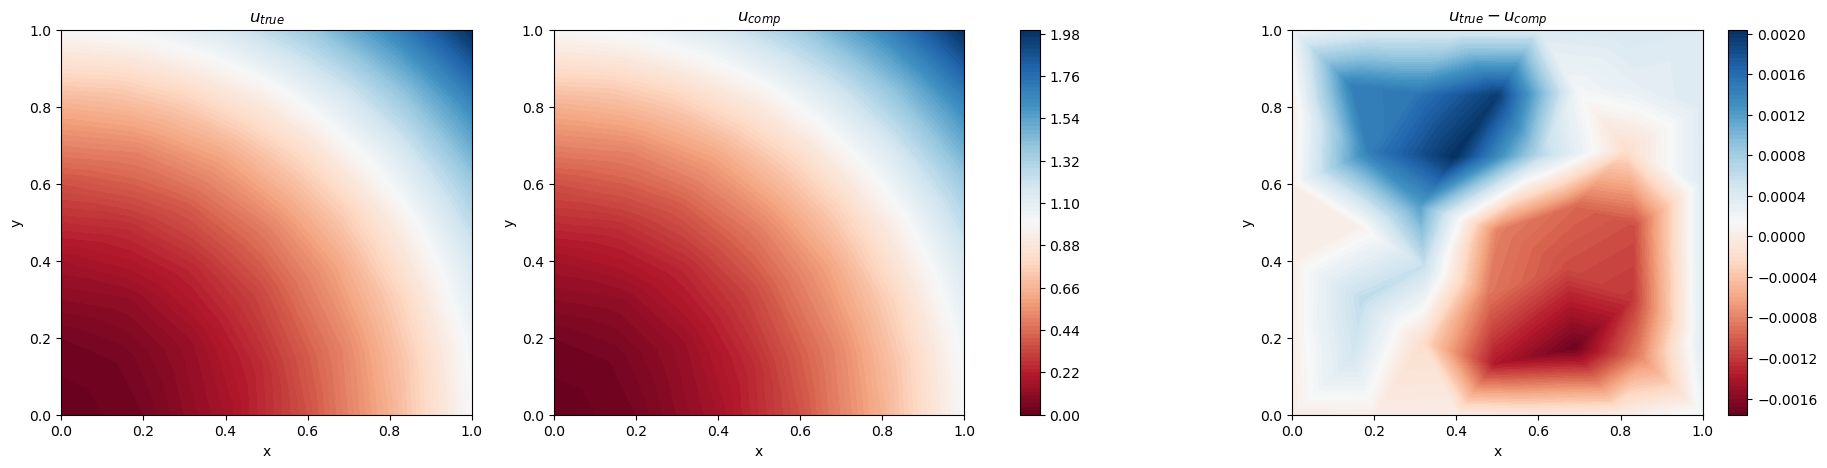

In [14]:
# contour plot
triang = tri.Triangulation(S.node_coords[:, 0], S.node_coords[:, 1], S.S[2])
plt.figure(1, figsize=(22.5, 5))
_, ax = plt.subplots(1, 3, num=1)

vmin = min(u_true.min(), u_var.min())
vmax = max(u_true.max(), u_var.max())

u_true_plot = ax[0].tricontourf(
    triang, u_true, cmap="RdBu", vmin=vmin, vmax=vmax, levels=100
)
u_plot = ax[1].tricontourf(
    triang, u_var, cmap="RdBu", vmin=vmin, vmax=vmax, levels=100
)
res_plot = ax[2].tricontourf(triang, u_true - u_var, cmap="RdBu", levels=100)

plt.colorbar(u_true_plot, ax=[ax[0], ax[1]], orientation="vertical")
plt.colorbar(res_plot, ax=ax[2], orientation="vertical")
for i in range(3):
    ax[i].set_xlabel("x")
    ax[i].set_ylabel("y")

ax[0].set_title(r"$u_{true}$")
ax[1].set_title(r"$u_{comp}$")
ax[2].set_title(r"$u_{true} - u_{comp}$")
plt.show()

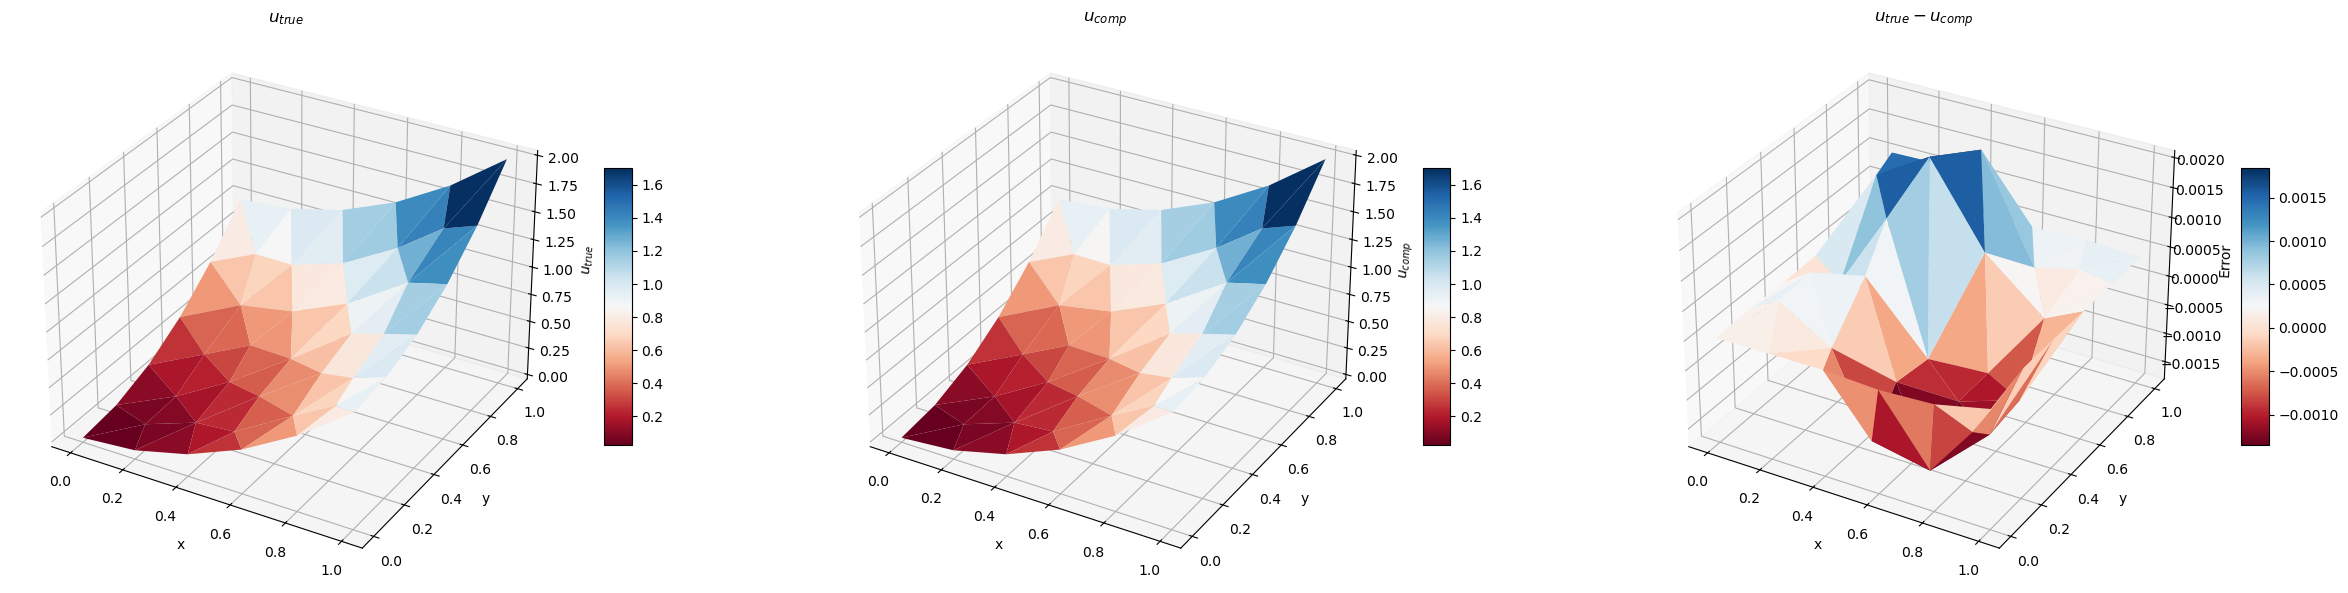

In [15]:
# Surface plot
fig = plt.figure(figsize=(25, 6))
ax0 = fig.add_subplot(1, 3, 1, projection="3d")

surf0 = ax0.plot_trisurf(
    triang, u_true, cmap="RdBu", linewidth=0.2, antialiased=True
)
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_zlabel(r"$u_{true}$")
ax0.set_title(r"$u_{true}$")
fig.colorbar(surf0, ax=ax0, shrink=0.5, aspect=10)
ax1 = fig.add_subplot(1, 3, 2, projection="3d")
surf1 = ax1.plot_trisurf(
    triang, u_var, cmap="RdBu", linewidth=0.2, antialiased=True
)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel(r"$u_{comp}$")
ax1.set_title(r"$u_{comp}$")
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)
ax2 = fig.add_subplot(1, 3, 3, projection="3d")
surf2 = ax2.plot_trisurf(
    triang, u_true - u_var, cmap="RdBu", linewidth=0.2, antialiased=True
)
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_zlabel("Error")
ax2.set_title(r"$u_{true} - u_{comp}$")
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()

# 3D Diffusion Equation

In [16]:
#pv.set_jupyter_backend('trame')
pv.global_theme = themes.ParaViewTheme()

In [17]:
lc = 0.2
mesh, _ = util.generate_cube_mesh(lc)
#pv.plot(mesh)
S = util.build_complex_from_mesh(mesh)
num_nodes = S.num_nodes
print("number of nodes = ", num_nodes)
print("number of tets = ", S.S[3].shape[0])
S.get_hodge_star()

number of nodes =  234
number of tets =  709


In [18]:
# boundary conditions
bottom_nodes = np.argwhere(S.node_coords[:,2]<1e-6).flatten()
top_nodes = np.argwhere(abs(S.node_coords[:,2]-1.)<1e-6).flatten()
values = np.zeros(len(bottom_nodes)+len(top_nodes), dtype=dt.float_dtype)
boundary_values = (np.hstack((bottom_nodes,top_nodes)), values)

In [19]:
def disspot(u, u_prev, deltat):
    u_coch = C.CochainP0(S, u)
    u_prev_coch = C.CochainP0(S, u_prev)
    u_diff = C.sub(u_coch, u_prev_coch)
    return (1/2)*C.inner(u_diff, u_diff)/deltat

def obj(u, u_prev, f, k, boundary_values, gamma, deltat):
    en = energy_poisson(x=u, f=f, k=k, boundary_values=boundary_values, gamma=gamma)
    return en + disspot(u, u_prev, deltat)

k = 1.
f_vec = np.ones(num_nodes, dtype=dt.float_dtype)
gamma = 1000.
deltat = 0.05

u_0 = np.zeros(num_nodes, dt.float_dtype)
u_prev = u_0

In [20]:
sols = []
prb = oc.OptimizationProblem(dim=num_nodes, state_dim=num_nodes, objfun=obj)
for i in range(10):
    print("t = ", (i+1)*deltat)
    args = {'u_prev': u_prev, 'f': f_vec, 'k': k, 'boundary_values': boundary_values,
        'gamma': gamma, 'deltat': deltat}
    prb.set_obj_args(args)
    u = prb.solve(u_prev, ftol_abs=1e-8, ftol_rel=1e-8)
    u_prev = u.__array__()
    sols.append(u)
prb.last_opt_result

t =  0.05
t =  0.1
t =  0.15000000000000002
t =  0.2
t =  0.25
t =  0.30000000000000004
t =  0.35000000000000003
t =  0.4
t =  0.45
t =  0.5


1

In [30]:
p = pv.Plotter()
p.add_mesh(mesh, scalars=sols[-1])
p.show()

Widget(value='<iframe src="http://localhost:41297/index.html?ui=P_0x79c88c0d1450_8&reconnect=auto" class="pyvi…